When n is larger than 1, there are functions of the form  $f:Σ^n → Σ$ that are neither constant nor balanced. <br>
For the Deutsch-Jozsa problem, they're considered to be "don't care" inputs. That is, for this problem we have a promise that $f$ is either constant or balanced.

The Deutsch-Jozsa algorithm works every time, always giving us the correct answer when the promise is met, and requires a single query. <br>
Any deterministic classical algorithm that correctly solves the Deutsch-Jozsa problem must make exponentially many queries: <br> $2^{n−1} +1$ queries are required in the worst case.

There is a catch, however, which is that probabilistic classical algorithms can solve the Deutsch-Jozsa problem with very high probability using just a few queries. In particular, if we simply choose a few different strings of length $n$ randomly, and query $f$ on those strings, it's unlikely that we'll get the same function value for all of them when $f$ is balanced.

To be specific, if we choose $k$ input strings $x_1,…,x_k ∈ Σ^n$ uniformly at random, evaluate $f(x_1),…,f(x_k)$, and answer 0 if the function values are all the same, and 1 if not, then we'll always be correct when $f$ is constant, and wrong in the case that $f$ is balanced with probability just $2^{−k+1}$. If we take $k=11$, for instance, this algorithm will answer correctly with probability greater than $99.9\%$.

### Deutsch Jozsa circuit

<img src="./images/Deutsch-Jozsa.svg" width=500>

If every one of the $n$ measurement outcomes is 0, then the function $f$ is constant; and otherwise, if at least one of the measurement outcomes is 1, then the function $f$ is balanced. <br>
Thus, the circuit described above is followed by a classical post-processing step in which the OR of the measurement outcomes is computed to produce the output. <br>
We need to know that the probability that every one of the $n$ measurement outcomes is 0.

output: 1 for constant 0 for balanced

$H∣a⟩ = \frac{1}{\sqrt2}\sum_{b∈{0,1}}(−1)^{ab}∣b⟩$

  
$H^{⊗n}∣x_{n−1}⋯x_1x_0⟩=(H∣x_{n−1}⟩)⊗⋯⊗(H∣x_0⟩)$ <br>
$ = \frac{1}{\sqrt{2n}}∑_{y_{n−1}⋯y_0∈Σ^n}(−1)^{x_{n−1}y_{n−1}+⋯+x_0y_0}∣y_{n−1}⋯y_0⟩$
​
 


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

In [3]:
def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function satisfying the promise for the Deutsch-Jozsa problem.
 
    qc = QuantumCircuit(num_qubits + 1)
 
    if np.random.randint(0, 2):     # generate random integer 0(inclusive) to 2(exclusive)
        # Flip output qubit with 50% chance
        qc.barrier()
        qc.x(num_qubits)    # apply Pauli-X gate to qubit at index num_qubits (output qubit) which is bottommost/leftmost
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc
 
    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once, no duplicates
    )
 
    def add_x(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)): # reversed because we want to start from the least significant (leftmost/topmost) bit and then generate an iterator of (index, value) pairs.
            if bit == "1":
                qc.x(qubit)
        return qc
 
    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_x(qc, f"{state:0b}")  # f"{state:0b}" converts state to its binary representation as a string
        # Apply multi-controlled X gate
        qc.mcx(list(range(num_qubits)), num_qubits) # control qubits are all qubits except the last one, target qubit is the last one/output qubit
        qc = add_x(qc, f"{state:0b}")

    qc.barrier()
 
    return qc

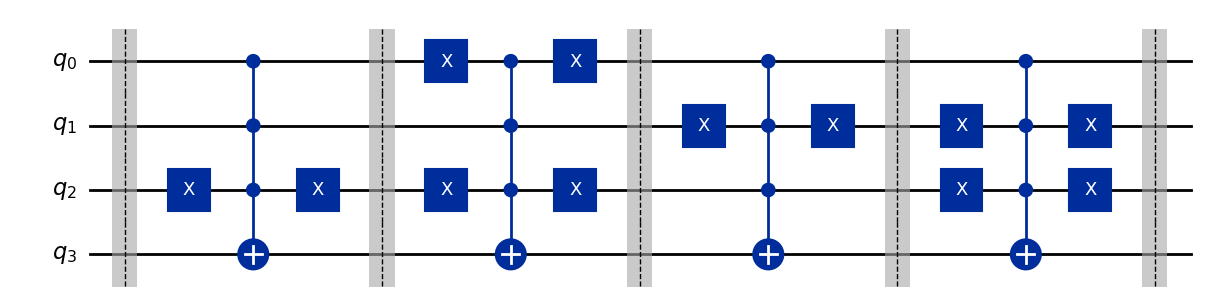

In [4]:
display(dj_query(3).draw(output="mpl"))

In [5]:
def dj_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm.
 
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)   # n input qubits + 1 output qubit, n classical bits for measurement
 
    qc.x(n)     # Not gate on the output qubit
    qc.h(range(n + 1)) # Hadamard on all qubits
 
    qc.compose(function, inplace=True)      # oracle

    qc.h(range(n))      # Hadamard on input qubits
    qc.measure(range(n), range(n))      # measure the n input qubits on n classical bits

    return qc

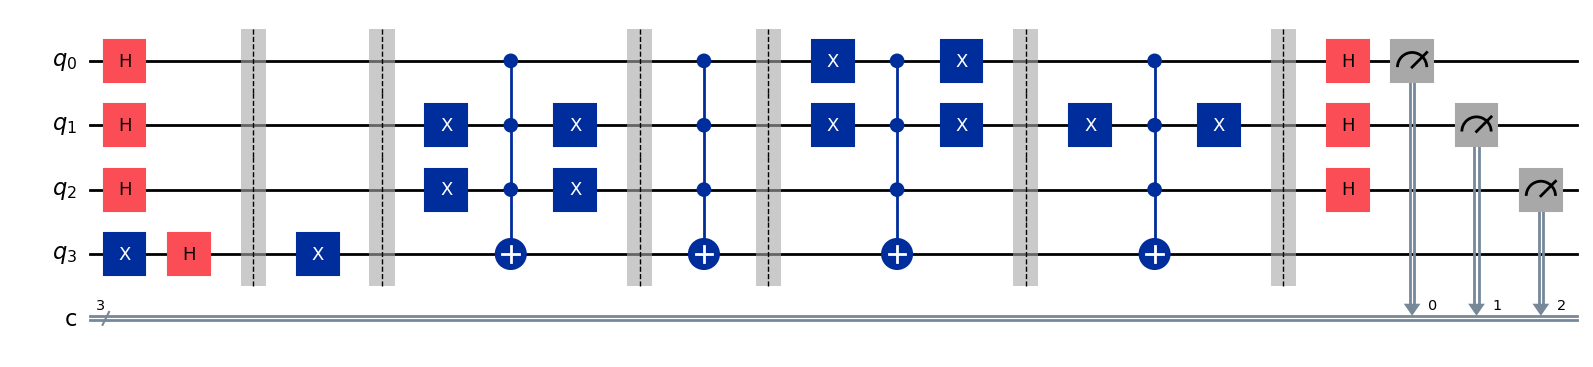

In [6]:
f = dj_query(3)
display(dj_circuit(f).draw(output="mpl"))

In [7]:
def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.

    qc = dj_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

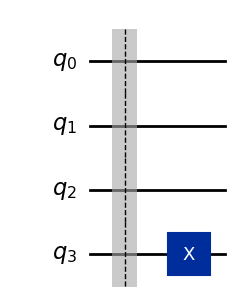

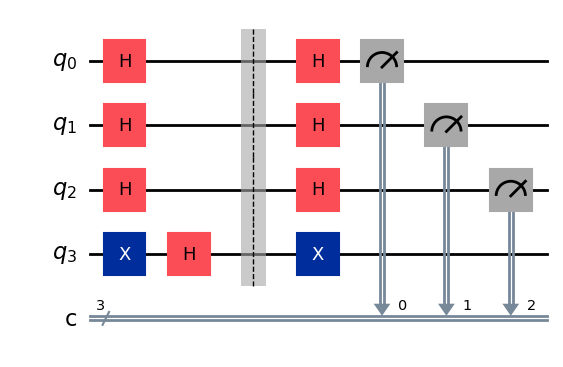

'constant'

In [8]:
f = dj_query(3)
display(f.draw("mpl"))
djc = dj_circuit(f)
display(djc.draw("mpl"))
dj_algorithm(f)

Binary dot Product \
$x⋅y = x_{n−1}y_{n−1}⊕⋯⊕x_0y_0$

$x⋅y = \begin{cases} 
1 & \text{if } x_{n−1}y_{n−1}+\cdots+x_0y_0 \text{ is odd} \\
0 & \text{if } x_{n−1}y_{n−1}+\cdots+x_0y_0 \text{ is even}
\end{cases}$

This is a symmetric operation, meaning that the result doesn't change if we swap $x$ and $y$ \
Binary dot product is the parity of the bits of x in positions where the string y has a 1, or equivalently, the parity of the bits of y in positions where the string x has a 1.
​


#### Bernstein–Vazirani Problem

**Input:**  A function $f : \{0,1\}^n \to \{0,1\}$

**Promise:** There exists a binary string  $s = s_{n-1} s_{n-2} \cdots s_{0}$ for which $f(x) = s \cdot x$ for all $x∈Σ^n$
 
**Output:** The hidden binary string $s$.

$H^{⊗n}∣x⟩= \frac{1}{\sqrt{2^n}}∑_{y∈Σ^n}(−1)^{x⋅y}∣y⟩$

$(s⋅x)⊕(y⋅x)=(s⊕y)⋅x$


$\frac{1}{2^{n}}\sum _{x\in \Sigma^{n}}(-1)^{z\cdot x}=
                                                        \begin{cases}
                                                        1&\text{if\ }z=0^n \\
                                                        0&\text{if\ }z\ne 0^n
                                                        \end{cases}$

If $z=0^n$, then $z⋅x=0$ for every string $x∈Σ^n$, so the value of each term in the sum is 1, and we obtain 1 by summing and dividing by $2^n$. On the other hand, if any one of the bits of z is equal to 1, then the binary dot product z⋅x is equal to 0 for exactly half of the possible choices for $x∈Σ^n$ and 1 for the other half.

$s⊕y=0^n$ if and only if $y=s$.

It possible to solve the Bernstein-Vazirani problem classically by querying the function on each of the n strings having a single 1, in each possible position, and 0 for all other bits, which reveals the bits of s one at a time. Therefore, the advantage of quantum over classical algorithms for this problem is 1 query versus n queries.

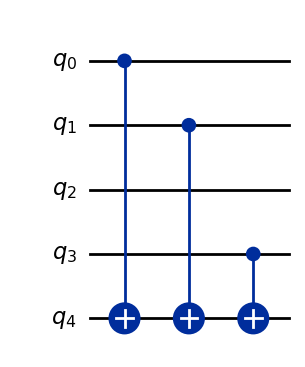

In [9]:
def bv_query(s):
    # Create a quantum circuit implementing a query gate for the
    # Bernstein-Vazirani problem.
 
    qc = QuantumCircuit(len(s) + 1)
    for index, bit in enumerate(reversed(s)):   # reversed because we want to start from the least significant (leftmost/topmost) bit and then generate an iterator of (index, value) pairs.
        if bit == "1":
            qc.cx(index, len(s))    # apply CNOT with control qubit at index and target qubit at len(s) (output qubit)
    return qc
 
 
display(bv_query("1011").draw(output="mpl"))

In [10]:
def bv_algorithm(function: QuantumCircuit):
    qc = dj_circuit(function)
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    return result.get_memory()[0]

In [11]:
secret_string = "0001"
bv_algorithm(bv_query(secret_string))

'0001'

Recursive Fourier sampling problem